# COMP0005 - GROUP COURSEWORK
# Experimental Evaluation of Search Data Structures and Algorithms

The cell below defines **AbstractSearchInterface**, an interface to support basic insert/search operations; you will need to implement this three times, to realise your three search data structures of choice among: (1) *2-3 Tree*, (2) *AVL Tree*, (3) *LLRB BST*; (4) *B-Tree*; and (5) *Scapegoat Tree*. <br><br>**Do NOT modify the next cell** - use the dedicated cells further below for your implementation instead. <br>

In [170]:
# DO NOT MODIFY THIS CELL

from abc import ABC, abstractmethod  

class AbstractSearchInterface(ABC):
    '''
    Abstract class to support search/insert operations (plus underlying data structure)
    
    '''
        
    @abstractmethod
    def insertElement(self, element):     
        '''
        Insert an element in a search tree
            Parameters:
                    element: string to be inserted in the search tree (string)

            Returns:
                    "True" after successful insertion, "False" if element is already present (bool)
        '''
        
        pass 
    

    @abstractmethod
    def searchElement(self, element):
        '''
        Search for an element in a search tree
            Parameters:
                    element: string to be searched in the search tree (string)

            Returns:
                    "True" if element is found, "False" otherwise (bool)
        '''

        pass

Use the cell below to define any auxiliary data structure and python function you may need. Leave the implementation of the main API to the next code cells instead.

In [171]:
# ADD AUXILIARY DATA STRUCTURE DEFINITIONS AND HELPER CODE HERE
class Node:
    def __init__(self,isLeaf=True):
        self._keys = []
        self._children = []
        self._isLeaf = isLeaf

    def addKey(self,key, pos = None):
        if pos == None:
            pos = len(self._keys)
        self._keys.insert(pos,key)
    
    def addChild(self,child_node,pos=None):
        if pos == None:
            pos = len(self._children)
        self._children.insert(pos,child_node)

    def getChildIndex(self,child):
        try:
            return self._children.index(child)
        except:
            return False
    
    def removeChild(self,child):
        self._children.remove(child)

    def getKeys(self):
        return self._keys
    
    def getChildren(self):
        return self._children
    
    def isLeaf(self):
        return self._isLeaf
    
    def setLeaf(self,leaf):
        self._leaf = leaf


class TreeNodeLLRBBST:
    def __init__(self, key):
        self.key = key
        self.left = None
        self.right = None
        #BLACK = False , RED = True
        self.color = False 



In [172]:
#Henry
class TwoThreeTree(AbstractSearchInterface):
    def __init__(self):
        self._root = None
        
    def insertElementRecursion(self, element): 
        if self._root == None: #Case 1: Empty tree
            self._root = Node()
            self._root.addKey(element)
            return True
        
        def traverseTree(element,currentNode,currentPath=None): #Traverse tree recursively to find where to place node
            if currentPath == None:
                currentPath = []
            currentNodeKeys = currentNode.getKeys()
            if element in currentNodeKeys:
                return False
            currentPath.append(currentNode)
            if currentNode.isLeaf():
                return currentPath
            
            children = currentNode.getChildren()

            if len(currentNodeKeys) == 0 or element < currentNodeKeys[0]:
                return traverseTree(element,children[0],currentPath)
            elif len(currentNodeKeys) == 1 or element < currentNodeKeys[1]:
                return traverseTree(element,children[1],currentPath)
            else:
                return traverseTree(element,children[2],currentPath)
        
        def addKeyToNode(node,element):
            keys = node.getKeys()
            if len(keys) == 0 or element < keys[0]:
                node.addKey(element,0)
            elif len(keys) == 1 or element < keys[1]:
                node.addKey(element,1)
            else:
                node.addKey(element,2)
            return node.getKeys()
        
        def addToTree(element,path):
            currentNode = path.pop()
            currentNodeKeys = addKeyToNode(currentNode,element)
            if len(currentNodeKeys) <= 2: #Adding to a 2-node
                return
            currentNodeChildren = currentNode.getChildren()
            currentLeaf = currentNode.isLeaf()
            isRoot = len(path) == 0

            if isRoot: #Adding to a 3-node and its a root node
                parentNode = Node(isLeaf=False)
                addKeyToNode(parentNode,currentNodeKeys[1])
                self._root = parentNode
                currentNodeIndex = 0
            else: #Adding to a 3-node
                parentNode = path[-1]
                currentNodeIndex = parentNode.getChildIndex(currentNode) #To add the new nodes in the correct position

            node1 = Node(currentLeaf) #Create new nodes 
            node1.addKey(currentNodeKeys[0])
            node2 = Node(currentLeaf)
            node2.addKey(currentNodeKeys[2])
            if currentLeaf == False: #Connect the new nodes to the rest of the tree if not leaf
                node1.addChild(currentNodeChildren[0])
                node1.addChild(currentNodeChildren[1])
                node2.addChild(currentNodeChildren[2])
                node2.addChild(currentNodeChildren[3])
            parentNode.removeChild(currentNode)
            parentNode.addChild(node1,currentNodeIndex) #Add nodes in correct spot, if left, positions 0,1, if right, positions 1,2
            parentNode.addChild(node2,currentNodeIndex+1)
            if isRoot == False:
                addToTree(currentNodeKeys[1],path) #Add middle key to previous node/new root node

        pathToLeaf = traverseTree(element,self._root)
        if pathToLeaf == False:
            return False
        addToTree(element,pathToLeaf)
        return True

    def searchElementRecrusion(self, element):     
        def search(element,currentNode):
            if (currentNode == None): #Check its not an empty tree
                return False
            currentNodeKeys = currentNode.getKeys()
            if element in currentNodeKeys: #Base case: Stops the recrusion, found item
                return True
            if currentNode.isLeaf(): #Base case: Stops the recrusion, end of tree
                return False

            currentNodeChildren = currentNode.getChildren()

            if element < currentNodeKeys[0]:
                return search(element,currentNodeChildren[0])
            elif len(currentNodeKeys) == 1 or element < currentNodeKeys[1]:
                return search(element,currentNodeChildren[1])
            elif element >= currentNodeKeys[1]:
                return search(element,currentNodeChildren[2])
    
        return search(element,self._root)
    
    def searchElement(self, element): #Python is not good for recursion so its done iteratively instead
        if self._root == None: #Check its not an empty tree
            return False
        currentNode = self._root
        while True:
            currentNodeKeys = currentNode.getKeys()
            found = element in currentNodeKeys
            if found == True: #Found element, stop looping
                return True
            currentNodeChildren = currentNode.getChildren()
            if len(currentNodeChildren) == 0: #Reached leaf, stop looping
                return False
            if element < currentNodeKeys[0]:
                currentNode = currentNodeChildren[0]
            elif len(currentNodeKeys) == 1 or element < currentNodeKeys[1]:
                currentNode = currentNodeChildren[1]
            elif element >= currentNodeKeys[1]:
                currentNode = currentNodeChildren[2]

    def insertElement(self, element):
        if self._root == None:
            self._root = Node()
            self._root.addKey(element)
            return True

        def getPathToLeaf(element): 
            currentNode = self._root
            pathToLeaf = [currentNode]
            while True:
                currentNodeKeys = currentNode.getKeys()
                found = element in currentNodeKeys
                if found == True: #Found element, stop looping
                    return False
                currentNodeChildren = currentNode.getChildren()
                if currentNode.isLeaf(): #Reached leaf, stop looping
                    return pathToLeaf
                if element < currentNodeKeys[0]:
                    currentNode = currentNodeChildren[0]
                elif len(currentNodeKeys) == 1 or element < currentNodeKeys[1]:
                    currentNode = currentNodeChildren[1]
                elif element >= currentNodeKeys[1]:
                    currentNode = currentNodeChildren[2]
                pathToLeaf.append(currentNode)
       
        def addKeyToNode(node,element):
            keys = node.getKeys()
            if len(keys) == 0 or element < keys[0]:
                node.addKey(element,0)
            elif len(keys) == 1 or element < keys[1]:
                node.addKey(element,1)
            else:
                node.addKey(element,2)
            return node.getKeys()
        
        pathToLeaf = getPathToLeaf(element)
        if pathToLeaf == False:
            return False
        
        for i in range(len(pathToLeaf)-1,-1,-1):
            currentNode = pathToLeaf[i]
            currentNodeKeys = addKeyToNode(currentNode,element)
            if len(currentNodeKeys) <= 2: #Adding to a 2-node
                return True
            currentNodeChildren = currentNode.getChildren()
            currentLeaf = currentNode.isLeaf()
            atRoot = currentNode == self._root 
            if atRoot: #Adding to a 3-node root node
                parentNode = Node(isLeaf=False)
                parentNode.addKey(currentNodeKeys[1])
                self._root = parentNode
                currentNodeIndex = 0
            else: #Adding to a 3-node
                parentNode = pathToLeaf[i-1]
                currentNodeIndex = parentNode.getChildIndex(currentNode) #To add the new nodes to the correct position 
                parentNode.removeChild(currentNode)

            node1 = Node(currentLeaf) #Create new nodes 
            node1.addKey(currentNodeKeys[0])
            node2 = Node(currentLeaf)
            node2.addKey(currentNodeKeys[2])
            if currentLeaf == False: #Connect the new nodes to the rest of the tree if not leaf
                node1.addChild(currentNodeChildren[0])
                node1.addChild(currentNodeChildren[1])
                node2.addChild(currentNodeChildren[2])
                node2.addChild(currentNodeChildren[3])
            
            parentNode.addChild(node1,currentNodeIndex) #Add nodes in correct spot, if left, positions 0,1, if right, positions 1,2
            parentNode.addChild(node2,currentNodeIndex+1)
            element = currentNodeKeys[1]
            if atRoot:
                return True
            

            
            
            

Use the cell below to implement the requested API by means of **AVL Tree** (if among your chosen data structure).

In [173]:
class AVLTree(AbstractSearchInterface):
        
    def insertElement(self, element):
        inserted = False
        # ADD YOUR CODE HERE
      
        
        return inserted
    
    

    def searchElement(self, element):     
        found = False
        # ADD YOUR CODE HERE

        
        return found  

Use the cell below to implement the requested API by means of **LLRB BST** (if among your chosen data structure).

In [174]:
#Alfie
BLACK = False
RED = True
    
class LLRBBST(AbstractSearchInterface):
    def __init__(self):
        self.root = None

    def __rotateLeft(self, n: TreeNodeLLRBBST):
        x = n.right
        n.right = x.left
        x.left = n
        x.color = n.color
        n.color = RED

        return x
    
    def __rotateRight(self, n: TreeNodeLLRBBST):
        x = n.left
        n.left = x.right
        x.right = n
        x.color = n.color
        n.color = RED

        return x
    
    def __flipColor(self, n: TreeNodeLLRBBST):
        #assumes left and right nodes are not None
        n.color = not n.color
        n.left.color = not n.left.color
        n.right.color = not n.right.color

    def __isRed(self, n: TreeNodeLLRBBST):
        return (n is not None and n.color == RED)
    
    def __insertRecursion(self, element, n: TreeNodeLLRBBST): 
        #check if node exists, if not insert element
        if n is None:
            newNode = TreeNodeLLRBBST(element)
            newNode.color = RED
            return (newNode, True)
        
        #duplicate key: do not insert
        if element == n.key: 
            return (n, False)
        
        #traverse down tree
        inserted = False
        if element < n.key: 
            (n.left, inserted) = self.__insertRecursion(element, n.left)
        elif element > n.key: 
            (n.right, inserted) = self.__insertRecursion(element, n.right)

        #rotate a temporary right-leaning to be left-leaning
        if (self.__isRed(n.right) and not self.__isRed(n.left)): n =  self.__rotateLeft(n)
        #fix two left left reds: rotate left-leaning to be temporary right-leaning
        if (self.__isRed(n.left) and self.__isRed(n.left.left)): n =  self.__rotateRight(n)
        #split 4-node: flips colours of parent and its children 
        if (self.__isRed(n.left) and self.__isRed(n.right)): self.__flipColor(n)

        return (n, inserted)
         
    def insertElement(self, element):
        inserted = False

        (self.root, inserted) = self.__insertRecursion(element, self.root)
        #root node is always black
        if self.root: self.root.color = BLACK

        return inserted


    def searchElement(self, element):
        found = False
        n = self.root
        
        #traverse down tree
        while n is not None:
            if element == n.key: 
                found = True
                break 
            elif element < n.key: n = n.left
            else: n = n.right
        
        return found 


Use the cell below to implement the requested API by means of **B-Tree** (if among your chosen data structure).

In [175]:
class BTree(AbstractSearchInterface):
        
    def insertElement(self, element):
        inserted = False
        # ADD YOUR CODE HERE
      
        
        return inserted
    
    

    def searchElement(self, element):     
        found = False
        # ADD YOUR CODE HERE

        
        return found

Use the cell below to implement the requested API by means of **Scapegoat Tree** (if among your chosen data structure).

In [176]:
class ScapegoatTree(AbstractSearchInterface):
        
    def insertElement(self, element):
        inserted = False
        # ADD YOUR CODE HERE
      
        
        return inserted
    
    

    def searchElement(self, element):     
        found = False
        # ADD YOUR CODE HERE

        
        return found 

Use the cell below to implement the **synthetic data generator** needed by your experimental framework (be mindful of code readability and reusability).

In [177]:
# Alex
import string
import random
from abc import ABC, abstractmethod

rand = random.Random(67) # for reproducibility

class StringNumber():

    def __init__(self, n: int = 0):
        self.n = n

    def __add__(self, other):
        if (isinstance(other, StringNumber)):
            return StringNumber(self.n + other.n)
        elif (isinstance(other, int)):
            return StringNumber(self.n + other)

    def __sub__(self, other):
        if (isinstance(other, StringNumber)):
            return StringNumber(self.n - other.n)
        elif (isinstance(other, int)):
            return StringNumber(self.n - other)
        
    def __radd__(self, other):
        return self.__add__(other)
    
    def __rsub__(self, other):
        return StringNumber(self.__sub__(other).n * -1)
    
    # In the spirit of ensuring data used is a string, we will use only strings that can actually be displayed in the terminal.
    # The number will be converted to a base (126-33 = 94) string that can be displayed.
    def __str__(self):
        nTemp  = self.n
        s = ""
        while nTemp > 0:
            s = chr((nTemp % 94) + 33) + s
            nTemp = nTemp // 94
        return s
    def __repr__(self):
        return self.__str__()

class FixedLengthRandomStringGenerator():

    def __next__(self):
        return "".join([chr(rand.randint(97,112)) for _ in range(8)]) # 128 bit entropy and short string so that equality checking does not affect results

    def __iter__(self):
        return self

class DecreasingStringGenerator():

    def __init__(self):
        self.n = StringNumber(10 ** 10) # we will probably not exceed this number, and it generates a small string

    def __next__(self):
        self.n-=1
        return str(self.n)
    
    def __iter__(self):
        return self

class IncreasingStringGenerator():

    def __init__(self):
        self.dec = DecreasingStringGenerator()
    
    def __next__(self):
        return next(self.dec)[::-1]
    
    def __iter__(self):
        return self

Use the cell below to implement the requested **experimental framework** (be mindful of code readability and reusability).

<module 'matplotlib.pyplot' from '/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/matplotlib/pyplot.py'>

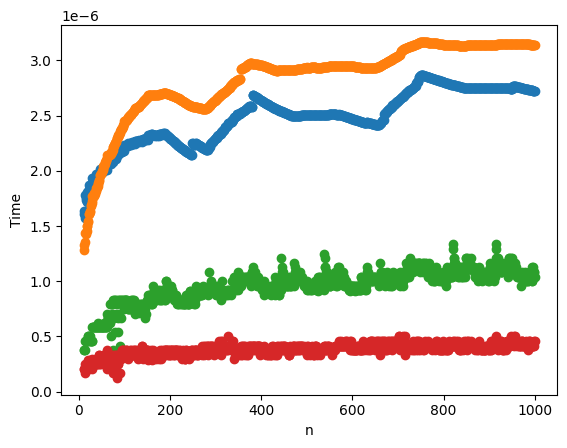

In [178]:
# Alex
import timeit
import matplotlib.pyplot as plt
import math

KILO = 10 ** 3
MEGA = 10 ** 6
GIGA = 10 ** 9

class DummySet(AbstractSearchInterface):
    def __init__(self):
        self.data = set()

    def insertElement(self, element):
        self.data.add(element)
    
    def searchElement(self, element):     
        return element in self.data


class TreeNode:
    __slots__ = ['element', 'left', 'right']
    def __init__(self, element):
        self.element = element
        self.left = None
        self.right = None


class BST(AbstractSearchInterface):
    def __init__(self):
        self.root = None

    def insertElement(self, element):
        # If the tree is empty, initialize the root
        if self.root is None:
            self.root = TreeNode(element)
            return True
        
        current = self.root
        while True:
            if element == current.element:
                # Element already exists
                return False
            
            elif element < current.element:
                # Go left
                if current.left is None:
                    current.left = TreeNode(element)
                    return True
                current = current.left
                
            else:
                # Go right
                if current.right is None:
                    current.right = TreeNode(element)
                    return True
                current = current.right

    def searchElement(self, element):
        current = self.root
        while current is not None:
            if element == current.element:
                return True
            elif element < current.element:
                current = current.left
            else:
                current = current.right
        return False


class Stats():
    pass


class Plotter():
    def __init__(self, x,y):
        self.x = x
        self.y = y
        self.xlabel = 'n'
        self.ylabel = 'Time'
    def floor_log10(n):
        if n == 0:
            return 0
        log = 0
        power = 1
        while power <= n:
            log += 1
            power *= 10
        return log - 1

    def fromTupledPoints(pts):
        x,y = zip(*pts)
        return Plotter(x,y)
    
    def add_tupled_points(self, pts):
        x,y = zip(*pts)
        plt.plot(x,y)
        return self
    
    def add_points(self, x,y):
        plt.plot(x,y)
        return self
    
    def plotting_log(self):
        self.x = [math.log(i) for i in self.x]
        self.xlabel ='logn'
        return self
    
    def plotting_constant(self):
        self.y = [v / Plotter.floor_log10(self.x[k]) for k,v in enumerate(self.y)]
        self.ylabel = 'Time/logn'
        return self
    
    def make_plot(self):
        plt.scatter(self.x, self.y)
        plt.ylabel(self.ylabel)
        plt.xlabel(self.xlabel)
        return plt


class ExperimentalFramework():
    def __init__(self, set : AbstractSearchInterface):
        self.set = set

    """
    https://docs.python.org/3/library/timeit.html#:~:text=Note%20It%E2%80%99s,statistics
    """
    def reduce_min(self, pts_list):
        n = len(pts_list)
        return [(pts_list[0][i][0], min(pts_list[j][i][1] for j in range(n))) for i in range(len(pts_list[0]))]
    

    def time_insert(self, strings, a, b):
        gen = iter(strings)
        self.set = type(self.set)() # empty set
        for _ in range(0, a):
            self.set.insertElement(next(gen))
        pts = []
        for i in range(a,b +1):
            s = next(gen)
            start = timeit.default_timer()
            self.set.insertElement(s) 
            end = timeit.default_timer()
            pts.append((i, end-start))
        return pts
    
    def time_insert_amortised(self, strings,a,b):
        gen = iter(strings)
        self.set = type(self.set)() # empty set
        if a > 0:
            pre_insert = timeit.default_timer()
            for _ in range(0, a):
                self.set.insertElement(next(gen))
            pre_insert = timeit.default_timer() - pre_insert
        else:
            pre_insert = 0
        total_time = pre_insert
        pts = []
        for i in range(a,b +1):
            s = next(gen)
            start = timeit.default_timer()
            self.set.insertElement(s)
            end = timeit.default_timer()
            total_time += (end - start)
            pts.append((i, total_time / i))
        return pts
    
    def time_search(self, strings,a,b):
        gen = iter(strings)
        self.set = type(self.set)() # empty set
        for _ in range(0, a):
            self.set.insertElement(next(gen))
        pts = []
        for i in range(a,b +1):
            s = next(gen)
            self.set.insertElement(s) # ensure the element is present for search
            start = timeit.default_timer()
            self.set.searchElement(s)
            end = timeit.default_timer()
            pts.append((i, end-start))
        return pts
    
    def plot_action(self, gen_type, action, a=1, b=GIGA, n=10):
        all_pts = []
        strings = [next(gen_type) for _ in range(0, b + 1)] # precache strings
        for _ in range(n):
            all_pts.append(action(strings, a, b))
        return Plotter.fromTupledPoints(self.reduce_min(all_pts))

exp1 = ExperimentalFramework(TwoThreeTree())
exp2 = ExperimentalFramework(LLRBBST())
exp1.plot_action(IncreasingStringGenerator(),exp1.time_insert_amortised,a=11,b=KILO,n=10).make_plot()
exp2.plot_action(IncreasingStringGenerator(),exp2.time_insert_amortised,a=11,b=KILO,n=10).make_plot()

exp1.plot_action(IncreasingStringGenerator(),exp1.time_search,a=11,b=KILO,n=10).make_plot()
exp2.plot_action(IncreasingStringGenerator(),exp2.time_search,a=11,b=KILO,n=10).make_plot()
# take top 2% and bottom 2%, divide by logn and plot log to show boundedness
#exp.plot_worst_case_search(b=MEGA)
    

Use the cell below to illustrate the python code you used to **fully evaluate** your three chosen search data structures and algortihms. The code below should illustrate, for example, how you made used of the **TestDataGenerator** class to generate test data of various size and properties; how you instatiated the **ExperimentalFramework** class to  evaluate each data structure using such data, collect information about their execution time, plot results, etc. Any results you illustrate in the companion PDF report should have been generated using the code below.

In [179]:
# ADD YOUR TEST CODE HERE 



